In [ ]:
import pandas as pd
df = pd.read_csv('data/quality_of_life_indices_by_country.csv')

: 

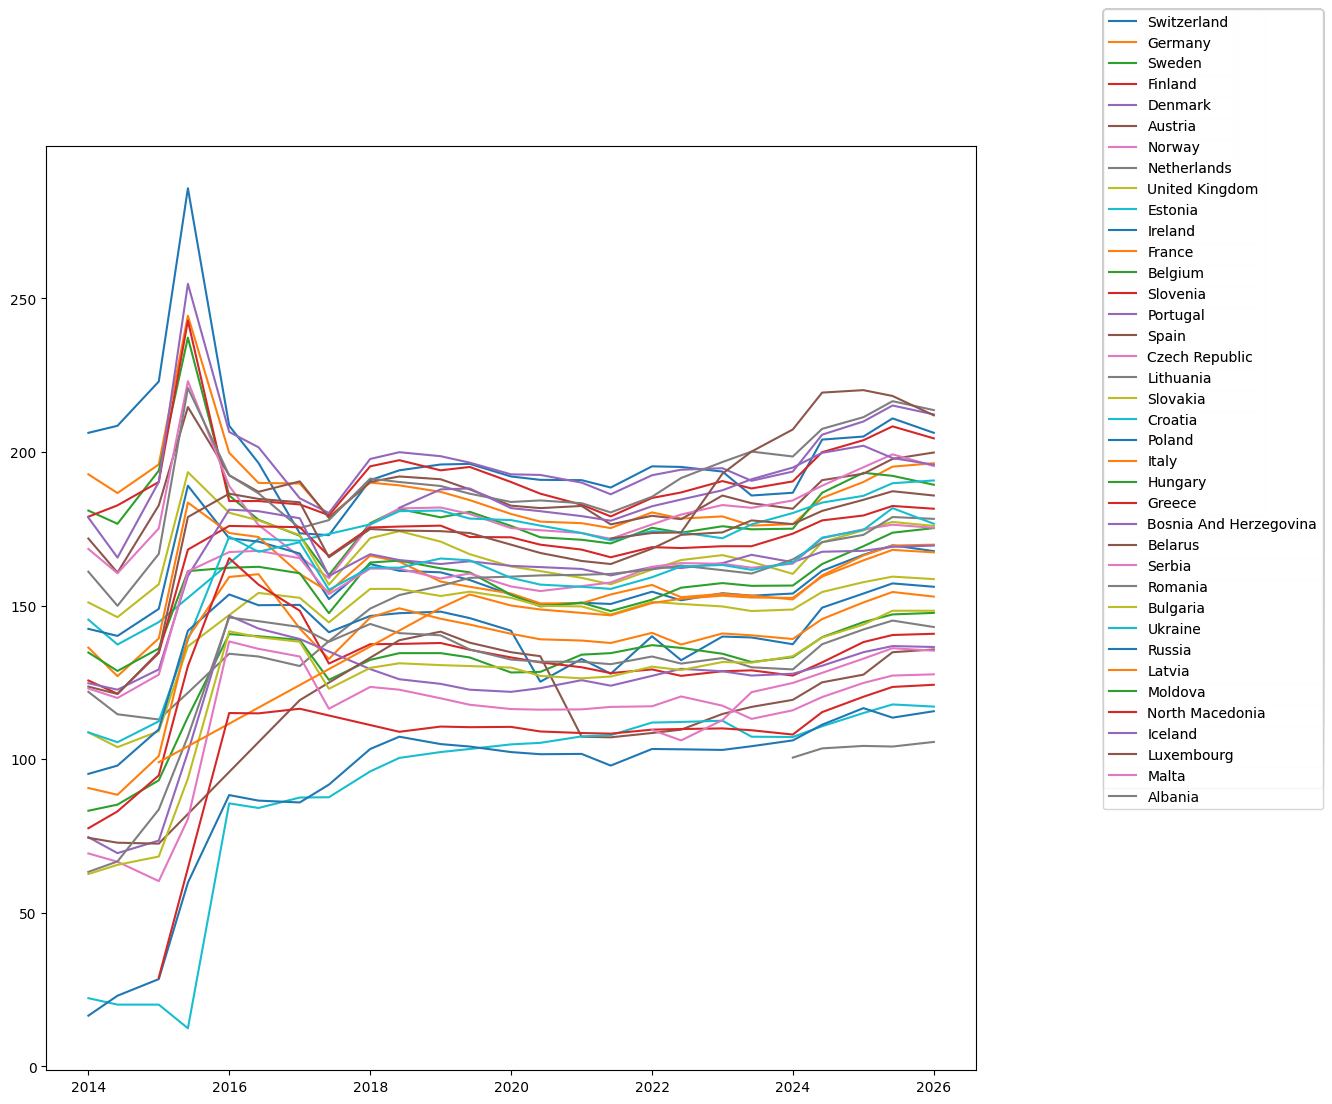

In [63]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 12))
for country in df['Country'].unique():
    country_data = df[df['Country'] == country]
    plt.plot(country_data['Year'], country_data['Quality of Life Index'], label=country)
    handles, labels = plt.gca().get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1, 1))

In [65]:
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
fig = go.Figure()
for country in df['Country'].unique():
    country_data = df[df['Country'] == country]
    fig.add_trace(go.Scatter(name=country, x=country_data['Year'], y=country_data['Quality of Life Index']))
fig.update_layout(title='Quality of Life Index by Country Over Time', xaxis_title='Year', yaxis_title='Quality of Life Index')
fig.show()

In [70]:
df.groupby("Country").agg({
    "Rank": 'mean',
    "Quality of Life Index": 'mean',
    "Purchasing Power Index": 'mean',
    "Safety Index": 'mean',
    "Health Care Index": 'mean',
    "Cost of Living Index": 'mean',
    "Property Price to Income Ratio": 'mean',
    "Traffic Commute Time Index": 'mean',
    "Pollution Index": 'mean',
    "Climate Index": "mean"
})

,Rank,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Climate Index
Country,,,,,,,,,,
Albania,36.800000,103.600000,41.640000,55.200000,48.600000,42.460000,14.980000,36.480000,77.120000,86.360000
Austria,5.800000,186.048000,95.852000,74.852000,78.180000,72.108000,10.332000,25.584000,24.004000,75.604762
Belarus,29.500000,116.590000,41.000000,58.435000,50.330000,33.780000,14.965000,29.695000,43.880000,62.317647
Belgium,17.320000,156.276000,95.116000,54.772000,76.920000,74.292000,6.756000,34.296000,51.052000,84.604762
Bosnia And Herzegovina,28.000000,121.820833,50.762500,57.187500,55.008333,37.216667,11.920833,25.483333,60.250000,79.540000
Bulgaria,27.240000,124.004000,53.448000,60.936000,55.924000,39.516000,8.940000,29.844000,63.512000,81.442857
Croatia,16.200000,157.144000,59.604000,73.680000,62.968000,51.652000,12.632000,28.548000,31.204000,88.009524
Czech Republic,16.240000,158.716000,73.736000,71.808000,73.736000,47.352000,12.988000,30.280000,38.504000,76.085714
Denmark,2.360000,196.980000,114.164000,74.668000,79.404000,85.456000,6.624000,28.128000,24.312000,79.847619


In [1]:
#zagotovitev da so stevila numericna
cols = [
    "Quality of Life Index", "Purchasing Power Index", "Safety Index",
    "Health Care Index", "Cost of Living Index",
    "Property Price to Income Ratio",
    "Traffic Commute Time Index", "Pollution Index", "Climate Index"
]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

NameError: name 'pd' is not defined

In [ ]:
# select only few countries (top growth + decline)

growth = df.groupby("Country")["Quality of Life Index"].agg(lambda x: x.iloc[-1] - x.iloc[0])

top = growth.sort_values(ascending=False).head(3)
bottom = growth.sort_values().head(3)

selected = list(top.index) + list(bottom.index)

df_small = df[df["Country"].isin(selected)]

In [ ]:
plt.figure(figsize=(10,6))

for country in df_small["Country"].unique():
    subset = df_small[df_small["Country"] == country]
    plt.plot(subset["Year"], subset["Quality of Life Index"], label=country)

plt.legend()
plt.title("Quality of Life - selected countries")
plt.xlabel("Year")
plt.ylabel("Index")
plt.show()

In [ ]:
top_growth = growth.sort_values(ascending=False).head(10)
print(top_growth)

In [ ]:
top_decline = growth.sort_values().head(10)
print(top_decline)

In [ ]:
corr = df[cols].corr()

print(corr["Quality of Life Index"].sort_values(ascending=False))

In [ ]:
df = df.fillna(df.mean(numeric_only=True))
plt.figure(figsize=(6,4))

plt.scatter(df["Purchasing Power Index"], df["Quality of Life Index"])
plt.xlabel("Purchasing Power")
plt.ylabel("Quality of Life")
plt.title("Relation between purchasing power and quality of life")

plt.show()

# Države katere imajo rast kakovosti in zakaj?

In [ ]:
Izračunali smo spremembo indeksa kakovosti življenja skozi čas.
Največjo rast imajo države, ki so izboljšale gospodarske razmere,
zdravstvo in varnost.

# Faktorji ki vplivajo na kakovost življenja?

In [ ]:
Opazili smo, da imajo največji vpliv na kakovost življenja
kupna moč, zdravstveni sistem in varnost.

Države z višjo kupno močjo imajo praviloma višji indeks kakovosti življenja.

# Države, pri katerih pada kakovost, in zakaj?


In [ ]:
Pri nekaterih državah opazimo padec kakovosti življenja.
To je lahko posledica višjih življenjskih stroškov, slabšega
zdravstva ali ekonomskih težav.